# Euler Bends

Two factory functions live in `kf.factories.euler`:

- `bend_euler_factory(kcl)` — clothoid 90° / arbitrary-angle bends.
- `bend_s_euler_factory(kcl)` — S-shaped (laterally offset) clothoid bends.

Unlike the DBU-native straight/taper factories, the euler factories take
`width` and `radius` in **µm**. The factory handles the µm→DBU conversion
internally.

In [1]:
import kfactory as kf
from kfactory.factories.euler import bend_euler_factory, bend_s_euler_factory


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)


pdk = kf.KCLayout("FACTORIES_EULER_DEMO", infos=LAYER)
L = LAYER()

## `bend_euler_factory` — 90° bends

90° euler bend: bend_euler_W0p5_R10_LWG_ENone_A90_R150


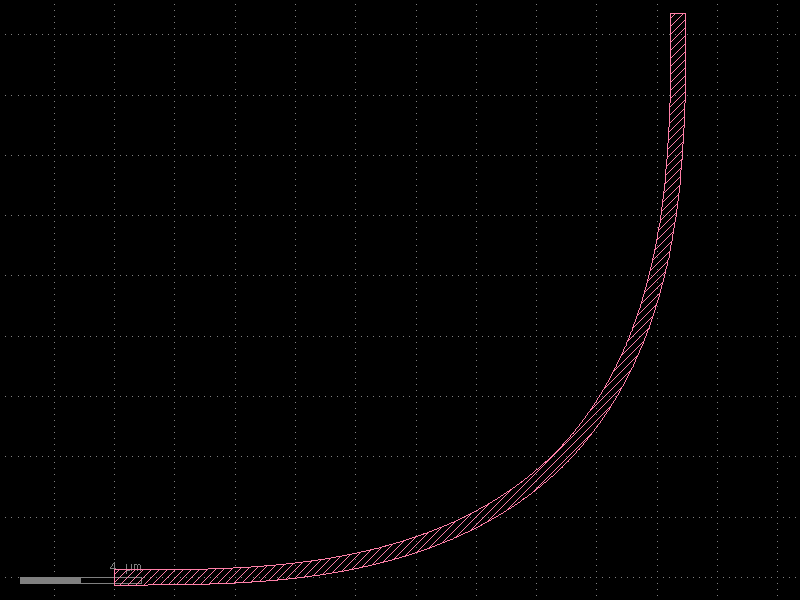

In [2]:
bend_euler = bend_euler_factory(pdk)

# 90° bend, 0.5 µm wide, 10 µm radius
b90 = bend_euler(width=0.5, radius=10.0, layer=L.WG)
print("90° euler bend:", b90.name)
b90

### Arbitrary angle

The `angle` parameter (degrees, default 90) produces partial euler bends.

45°  bend: bend_euler_W0p5_R10_LWG_ENone_A45_R150
180° bend: bend_euler_W0p5_R10_LWG_ENone_A180_R150


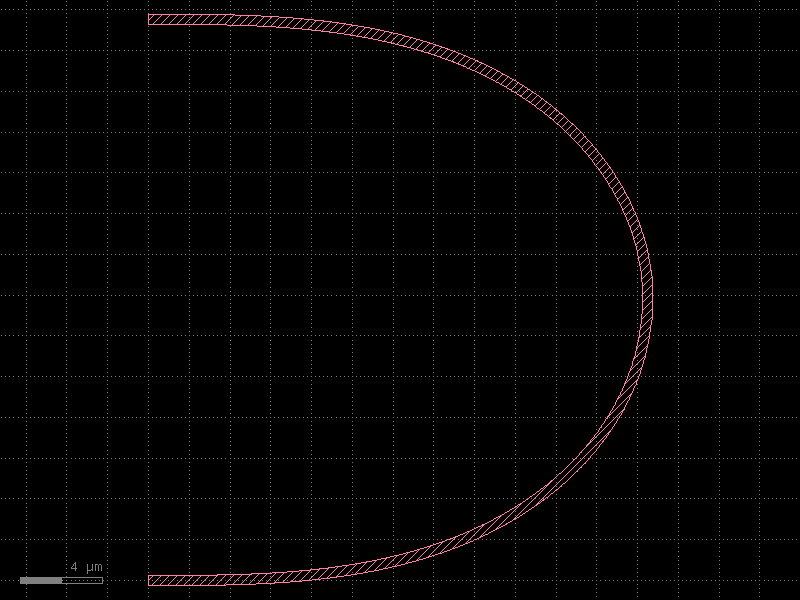

In [3]:
b45 = bend_euler(width=0.5, radius=10.0, layer=L.WG, angle=45.0)
b180 = bend_euler(width=0.5, radius=10.0, layer=L.WG, angle=180.0)
print("45°  bend:", b45.name)
print("180° bend:", b180.name)
b180

### Effective radius

Euler bends are clothoid curves — the actual footprint extends beyond the
nominal radius. Use `kf.routing.optical.get_radius(bend)` to get the footprint
radius for routing spacing calculations.

In [4]:
footprint_r = kf.routing.optical.get_radius(b90)
print(f"nominal radius: 10.0 µm, footprint radius: {footprint_r:.3f} µm")

nominal radius: 10.0 µm, footprint radius: 18701.000 µm


## `bend_s_euler_factory` — S-bends

`bend_s_euler_factory(kcl)` creates S-shaped (offset) bends. The `offset`
argument controls the lateral displacement (µm); a negative value flips the
direction of the offset.

S-bend: bend_s_euler_O5_W0p5_R10_LWG_ENone_R150


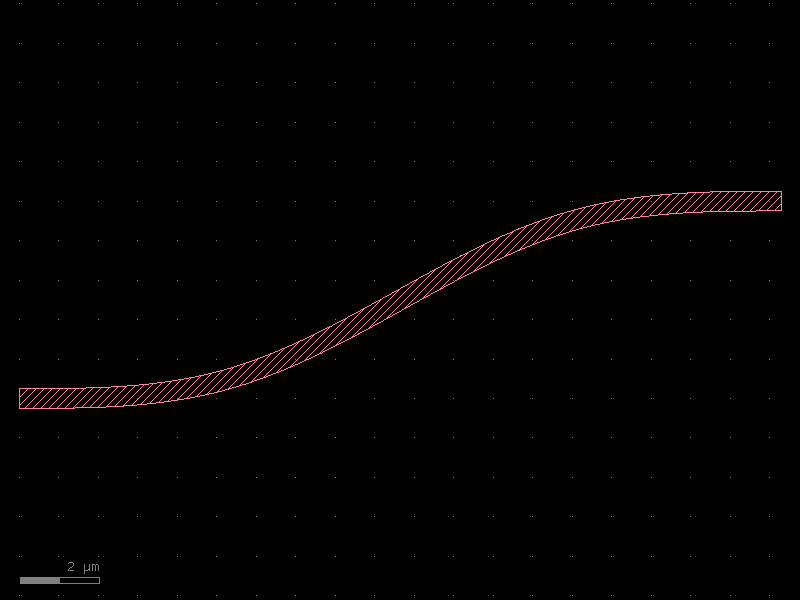

In [5]:
sbend_euler = bend_s_euler_factory(pdk)

sbend = sbend_euler(offset=5.0, width=0.5, radius=10.0, layer=L.WG)
print("S-bend:", sbend.name)
sbend

## See Also

| Topic | Where |
|-------|-------|
| Optical routing with euler bends | [Routing: Optical](../../../routing/optical.py) |